# The Half Day 🕑
### A couple of times a year the exchange shuts at one o'clock. Does the tape notice?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

The Friday after Thanksgiving, the day before the Fourth of July, Christmas Eve: the NYSE
rings the closing bell at 1 p.m., the volume drops off a cliff, and every year someone on a
trading forum explains that this is when the market drifts quietly upward because the
grown-ups have gone home. This notebook goes and looks.

> 📓 **This is the plain-language layer.** The statistics, the multiple-testing
> arithmetic and the cost maths live in the companion notebook,
> **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** An educational, reproducible research tool: every chart
> below is generated by the code beside it. House style in
> [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first 🎯

| Question | Answer |
|---|---|
| Is the half day genuinely empty? | **Yes** — and it is the only thing here that is not in doubt. |
| Does the market drift up on it? | Not measurably. The gap against an ordinary session is a rounding error next to its own error bar. |
| Could you trade it if it were real? | About **two** of these a year. Two sessions cannot pay for two round trips plus your attention. |

Everything below is why.

## 1 · The claim

> *"Half days are free money. Volume is a third of normal, the algos are off, the desk is on
> a train to Connecticut, and the tape just floats up until one o'clock."*

It is a good story, and it has a respectable ancestor: the **holiday effect** (Lakonishok &
Smidt 1988; Ariel 1990) found unusually strong returns on the session *before* a market
holiday, in ninety years of data. The half day is the most extreme version of that session —
the one the exchange itself cuts short.

## 2 · So what?

Two things ride on it. The small one: if the half day really drifts, a patient holder should
be *in* on those days and could skip a few others. The large one: the half day is a clean
natural experiment in **an empty market**. If prices behave differently when almost nobody is
trading, that tells you something about who sets prices the rest of the time.

## 3 · How would we even know?

First problem: *which days?* Typing a list of early closes from memory is how a calendar
study quietly breaks. So we derive candidates from the rule — July 3, the Friday after
Thanksgiving, December 24 — and then make the **tape** confirm each one: a real 1 p.m.
session prints a fraction of a normal day's volume.

Second problem: there are only about three a year, so the sample is tiny and any single
number will look impressive by accident. We will keep score of how many "discoveries" we
make and how many pure luck would hand us.

In [2]:
from half_day import data, strategy as st

bars = data.load_all()
sessions = {tk: st.session_frame(b) for tk, b in bars.items()}
spy = sessions["SPY"]
cands = st.rule_candidates(spy.index)
conf = st.confirm_candidates(spy, cands)
half_days = conf.index[conf["confirmed"]]
print(f"as-of {data.AS_OF} | SPY bars {len(spy):,} "
      f"({spy.index[0].date()} -> {spy.index[-1].date()})")
print(f"rule candidates {len(cands)} | confirmed by the volume tape {len(half_days)} "
      f"| {len(half_days) / ((spy.index[-1] - spy.index[0]).days / 365.25):.1f} per year")
conf.tail(9)

as-of 2026-06-30 | SPY bars 8,410 (1993-02-01 -> 2026-06-30)
rule candidates 70 | confirmed by the volume tape 62 | 1.9 per year


,family,volume_ratio,r_cc,confirmed
date,,,,
2022-11-25,black_friday,0.3464,-0.0002,True
2023-07-03,jul3,0.4227,0.0012,True
2023-11-24,black_friday,0.3682,0.0006,True
2024-07-03,jul3,0.6399,0.0045,True
2024-11-29,black_friday,0.7022,0.0062,True
2024-12-24,dec24,0.7923,0.0111,False
2025-07-03,jul3,0.7295,0.0079,True
2025-11-28,black_friday,0.6468,0.0055,True
2025-12-24,dec24,0.5004,0.0035,True


### The one thing nobody disputes: the exchange really is empty

The volume ratio below is each day's volume against the median of the 60 sessions *before*
it, so the benchmark can never be contaminated by the day being judged.

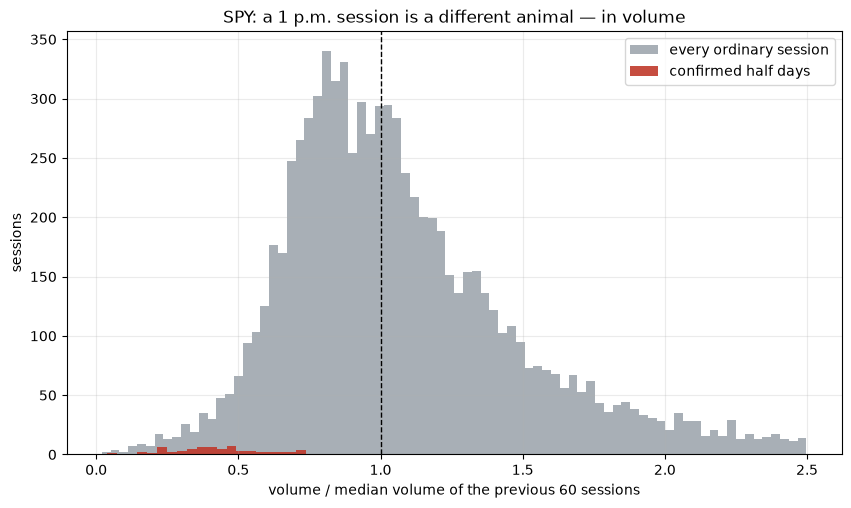

median volume ratio, half days : 0.42
median volume ratio, all others: 1.01


In [3]:
vr = spy["volume_ratio"].dropna()
fig, ax = plt.subplots()
ax.hist(vr[vr < 2.5], bins=80, color="#8b949e", alpha=0.75, label="every ordinary session")
ax.hist(vr.reindex(half_days).dropna(), bins=20, color="#c0392b", alpha=0.9,
        label="confirmed half days")
ax.axvline(1.0, color="k", lw=1, ls="--")
ax.set_xlabel("volume / median volume of the previous 60 sessions")
ax.set_ylabel("sessions")
ax.set_title("SPY: a 1 p.m. session is a different animal — in volume")
ax.legend()
plt.show()
print(f"median volume ratio, half days : {vr.reindex(half_days).median():.2f}")
print(f"median volume ratio, all others: {vr.drop(half_days, errors='ignore').median():.2f}")

## 4 · The teardown — let's actually look

Now the return. Below: every confirmed half day's close-to-close return, in order, with the
average of all *other* sessions drawn as the line to beat. If the folklore were right, the
dots would sit above the line more often than not, and by a visible margin.

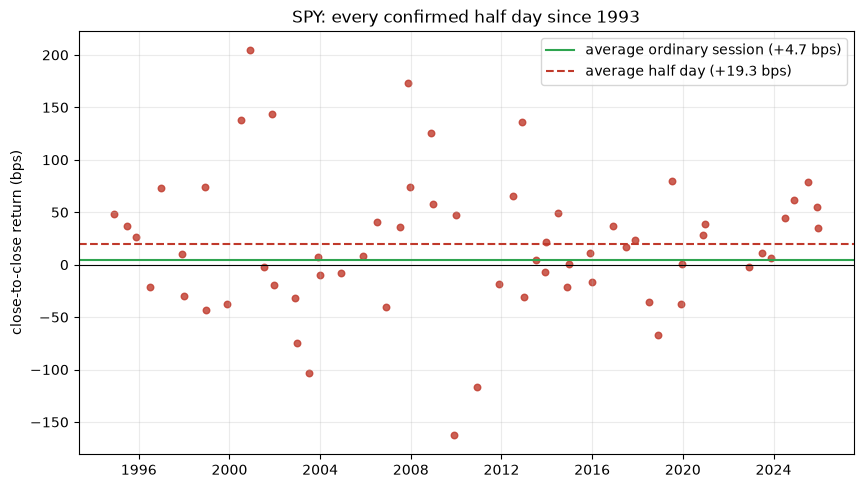

half days up: 63% of 62   ordinary sessions up: 54%


In [4]:
r = spy["r_cc"]
ev = r.reindex(half_days).dropna()
rest_mean = r.drop(ev.index).mean()
fig, ax = plt.subplots()
ax.axhline(0, color="k", lw=0.8)
ax.axhline(rest_mean * 1e4, color="#2ea44f", lw=1.5,
           label=f"average ordinary session ({rest_mean * 1e4:+.1f} bps)")
ax.axhline(ev.mean() * 1e4, color="#c0392b", lw=1.5, ls="--",
           label=f"average half day ({ev.mean() * 1e4:+.1f} bps)")
ax.scatter(ev.index, ev * 1e4, s=22, color="#c0392b", alpha=0.8)
ax.set_ylabel("close-to-close return (bps)")
ax.set_title("SPY: every confirmed half day since 1993")
ax.legend()
plt.show()
print(f"half days up: {(ev > 0).mean():.0%} of {len(ev)}   "
      f"ordinary sessions up: {(r.drop(ev.index) > 0).mean():.0%}")

> 🔬 **For the quants.** The scatter is the whole sample. Roughly ninety dots,
> visibly dominated by their own dispersion: an eyeball estimate of the standard error of
> that mean is already enough to know the answer before the *t*-test runs.

### Does the *window* around it behave?

Maybe the drift is the day *before* (the classic pre-holiday effect) or the day *after* (the
return of the grown-ups). Three windows, five tapes.

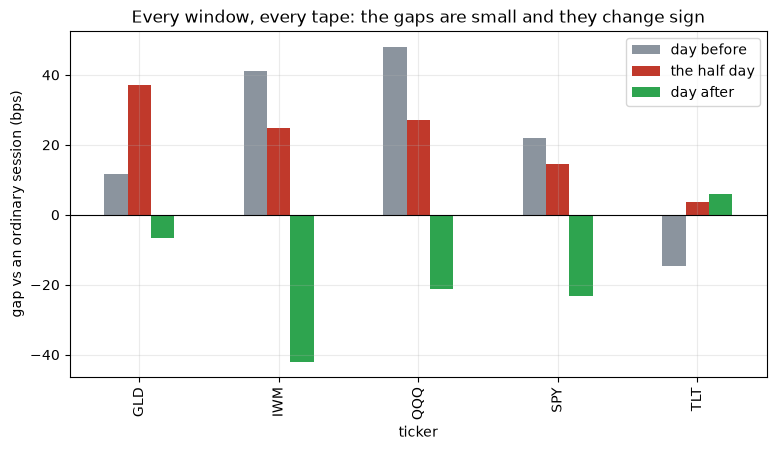

window,day before,the half day,day after
ticker,,,
GLD,11.6000,37.1000,-6.6000
IWM,41.2000,24.8000,-42.0000
QQQ,48.1000,27.1000,-21.2000
SPY,21.9000,14.7000,-23.1000
TLT,-14.7000,3.7000,5.8000


In [5]:
rows = []
for tk, s in sessions.items():
    c = st.confirm_candidates(s, st.rule_candidates(s.index))
    d = c.index[c["confirmed"]]
    for off, tag in ((-1, "day before"), (0, "the half day"), (1, "day after")):
        g = st.group_stats(s["r_cc"], st.event_mask(s, d, off))
        rows.append({"ticker": tk, "window": tag, "gap_bps": g["diff_bps"], "t": g["t_diff"]})
tbl = pd.DataFrame(rows).pivot(index="ticker", columns="window", values="gap_bps")
tbl = tbl[["day before", "the half day", "day after"]]
fig, ax = plt.subplots(figsize=(9, 4.5))
tbl.plot.bar(ax=ax, color=["#8b949e", "#c0392b", "#2ea44f"], edgecolor="none")
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("gap vs an ordinary session (bps)")
ax.set_title("Every window, every tape: the gaps are small and they change sign")
ax.legend(title="")
plt.show()
tbl.round(1)

The bars change sign from tape to tape and from window to window. That is what noise
looks like: a real calendar effect does not politely reverse itself between SPY and QQQ.

## 5 · The verdict

**Signal: Weak.** The volume collapse is unmistakable — a confirmed 1 p.m. session trades **42%** of a normal day's shares. The *return* is the fragile part: SPY's half day gaps **+14.7 bps** against an ordinary session (*t* = +1.77, CI includes zero), and of the **15** half-day cells (5 tickers x 3 families) **3** clear |*t*| = 2 against 0.75 expected by luck — all positive, none reaching |*t*| = 2.5, and the five tapes are not five independent tests. The sharper cells in the wider battery (9 of 45) sit at offset −1: that is the known pre-holiday effect, not the half day.

**Tradability: Fragile.** About **1.9 confirmed sessions a year**. The largest gap in the lot (GLD +37.1 bps/session, CI [-11, +85]) grosses +68.9 bps a year and nets **+65.2 bps** after a 1 bp round trip — a real number attached to an interval that contains zero, harvested twice a year. Break-even is **18.6 bps** one-way.

## 6 · Could you actually trade it?

Here is the arithmetic that ends the discussion, and it has nothing to do with statistics.
Whatever the edge per session is, you get it about **three times a year**, and each time you
pay to get in and to get out.

In [6]:
spy_gap = st.group_stats(spy["r_cc"], st.event_mask(spy, half_days, 0))["diff_bps"]
per_year = len(half_days) / ((spy.index[-1] - spy.index[0]).days / 365.25)
tbl = st.cost_arithmetic(spy_gap, per_year)
print(f"SPY gap per half-day session: {spy_gap:+.1f} bps   sessions per year: {per_year:.1f}")
print(f"break-even one-way cost     : {st.breakeven_cost_bps(spy_gap):.1f} bps")
(tbl[["gross_bps_per_year", "net_bps_per_year"]]).round(1)

SPY gap per half-day session: +14.7 bps   sessions per year: 1.9
break-even one-way cost     : 7.3 bps


,gross_bps_per_year,net_bps_per_year
cost_bps_one_way,,
0.0000,27.2000,27.2000
1.0000,27.2000,23.5000
2.0000,27.2000,19.8000
5.0000,27.2000,8.6000
10.0000,27.2000,-9.9000


## 7 · Going further 🚪

- The **variance** question is more interesting than the return one: a 2.5-hour session
  should carry roughly 2.5 hours of variance. Does it? (It mostly does — see the quants'
  notebook, and French & Roll 1986 for the classic version of the experiment.)
- Bond markets close at 2 p.m. on those days and sometimes on days the stock market does
  not. A cross-market version of this study has a bigger sample.
- The one-off early closes — a state funeral, a hurricane — are the cleanest natural
  experiment of all, because nobody could position for them in advance.